In [1]:
import tensorflow as tf

# List all available physical devices (GPUs)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
import sys
import os

PROJECT_ROOT = r"D:\MS\CSE715\VAE-for-Hybrid--Language-Music-Clustering"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Added to sys.path:", PROJECT_ROOT)

Added to sys.path: D:\MS\CSE715\VAE-for-Hybrid--Language-Music-Clustering


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.dataset import load_msd_h5_features

In [4]:
AUDIO_DIR = "../data/audio"

X, ids, feature_names = load_msd_h5_features(AUDIO_DIR, max_files=20000)

# Inspect the values
print("X shape:", X.shape)
print("Feature names:", feature_names)
print("IDs:", ids)

# If X is empty, it could mean no data was loaded properly
if X is not None and X.shape[0] > 0:
    df = pd.DataFrame(X, columns=feature_names)
    print("Loaded feature matrix:", df.shape)
    display(df.head())
else:
    print("No data loaded or the data matrix is empty.")

X shape: (10000, 6)
Feature names: ['tempo', 'loudness', 'duration', 'key', 'mode', 'time_signature']
IDs: ['TRAAAAW128F429D538', 'TRAAABD128F429CF47', 'TRAAADZ128F9348C2E', 'TRAAAEF128F4273421', 'TRAAAFD128F92F423A', 'TRAAAMO128F1481E7F', 'TRAAAMQ128F1460CD3', 'TRAAAPK128E0786D96', 'TRAAARJ128F9320760', 'TRAAAVG12903CFA543', 'TRAAAVO128F93133D4', 'TRAABCL128F4286650', 'TRAABDL12903CAABBA', 'TRAABJL12903CDCF1A', 'TRAABJV128F1460C49', 'TRAABLR128F423B7E3', 'TRAABNV128F425CEE1', 'TRAABRB128F9306DD5', 'TRAABVM128F92CA9DC', 'TRAABXG128F9318EBD', 'TRAABYN12903CFD305', 'TRAABYW128F4244559', 'TRAACCG128F92E8A55', 'TRAACER128F4290F96', 'TRAACFV128F935E50B', 'TRAACHN128F1489601', 'TRAACIW12903CC0F6D', 'TRAACLV128F427E123', 'TRAACNS128F14A2DF5', 'TRAACOW128F933E35F', 'TRAACPE128F421C1B9', 'TRAACQT128F9331780', 'TRAACSL128F93462F4', 'TRAACTB12903CAAF15', 'TRAACVS128E078BE39', 'TRAACZK128F4243829', 'TRAADDS128F425C68B', 'TRAADED128F42741FD', 'TRAADEV128F9348C0A', 'TRAADHS12903CE70A9', 'TRAADIV1290

,tempo,loudness,duration,key,mode,time_signature
0,92.197998,-11.197,218.931793,1.0,0.0,4.0
1,121.274002,-9.843,148.035461,6.0,0.0,4.0
2,100.070000,-9.689,177.475464,8.0,1.0,1.0
3,119.292999,-9.013,233.403625,0.0,1.0,4.0
4,129.738007,-4.501,209.606079,2.0,1.0,4.0


In [5]:
print("\nMissing values per feature:")
print(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())


Missing values per feature:
tempo             0
loudness          0
duration          0
key               0
mode              0
time_signature    0
dtype: int64

Summary statistics:


,tempo,loudness,duration,key,mode,time_signature
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,122.915451,-10.485669,238.507523,5.276100,0.691100,3.564800
std,35.184414,5.399788,114.137512,3.554087,0.462063,1.266239
min,0.000000,-51.643002,1.044440,0.000000,0.000000,0.000000
25%,96.965752,-13.163250,176.032196,2.000000,0.000000,3.000000
50%,120.161003,-9.380000,223.059143,5.000000,1.000000,4.000000
75%,144.013245,-6.532500,276.375061,8.000000,1.000000,4.000000
max,262.828003,0.566000,1819.767700,11.000000,1.000000,7.000000


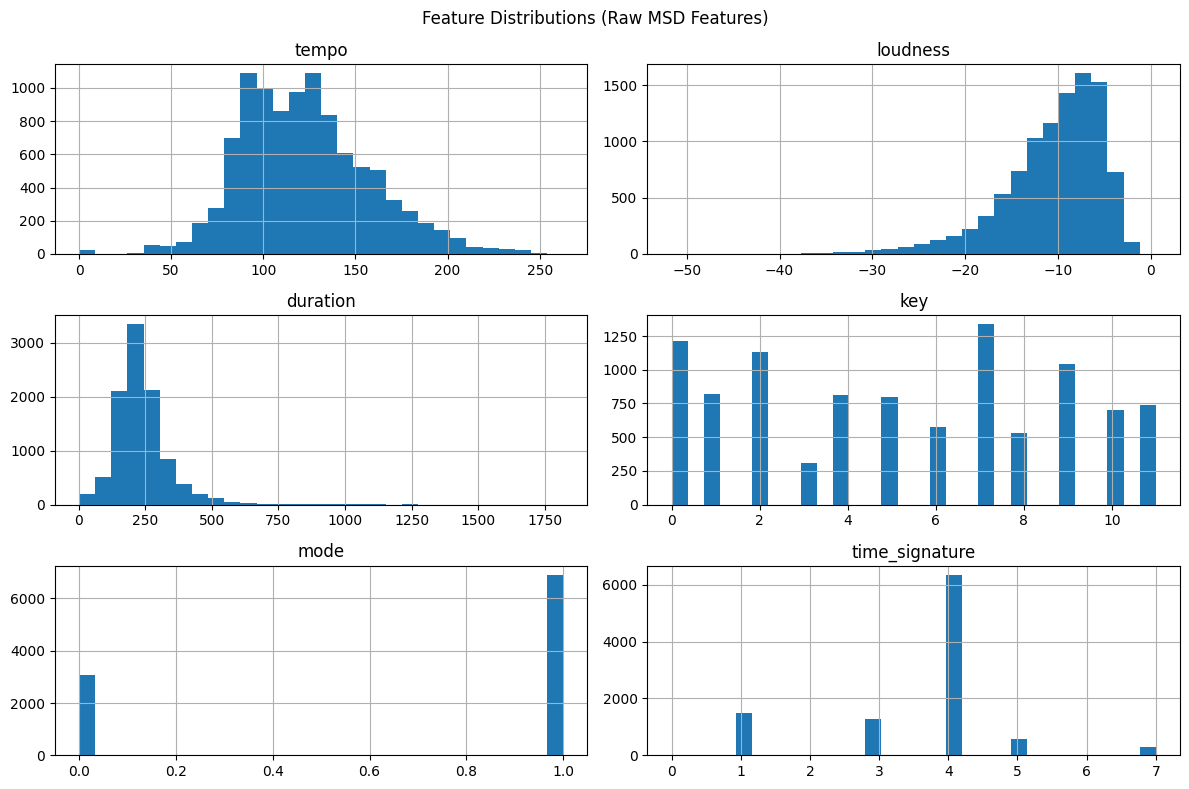

In [6]:
# Histograms
df.hist(bins=30, figsize=(12, 8))
plt.suptitle("Feature Distributions (Raw MSD Features)")
plt.tight_layout()
plt.show()

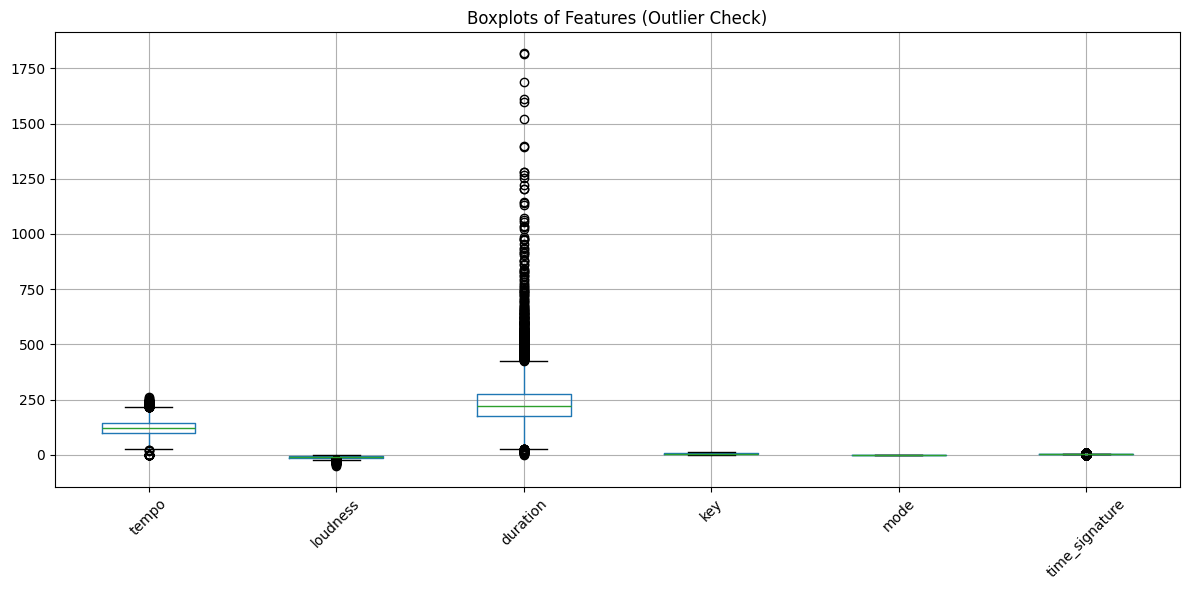

In [7]:
# Boxplot
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplots of Features (Outlier Check)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

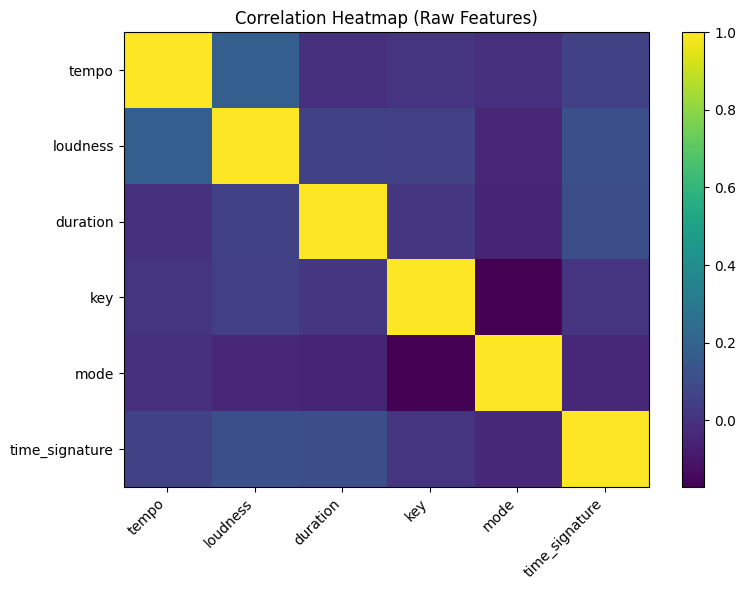

In [8]:
# Correlation heatmap (matplotlib only)
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Correlation Heatmap (Raw Features)")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from src.vae import build_vae
from src.clustering import kmeans_cluster, save_tsne_plot
from src.evaluation import easy_metrics, write_easy_metrics_csv

In [10]:
# Output paths (matches your directory)
TSNE_OUT = "../results/latent_visualization/vae_tsne.png"
CSV_OUT  = "../results/clustering_metrics.csv"

In [11]:
# 1) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

In [12]:
# ------------------------
# Baseline: PCA + KMeans
# ------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

labels_pca = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_pca)
sil_pca, ch_pca = easy_metrics(X_pca, labels_pca)

In [13]:
# ------------------------
# VAE + KMeans
# ------------------------
vae, encoder, decoder = build_vae(
    input_dim=X_scaled.shape[1],
    latent_dim=2,
    hidden_dim=64,
    beta=1.0
)


vae.fit(X_scaled, epochs=200, batch_size=64, verbose=1)

z_mean, z_log_var, z = encoder.predict(X_scaled)
Z = z_mean  # stable latent representation for clustering

labels_vae = kmeans_cluster(Z, n_clusters=5)
sil_vae, ch_vae = easy_metrics(Z, labels_vae)

Epoch 1/200
157/157 [==============================] - 5s 7ms/step - loss: 5.8404 - recon_loss: 5.1388 - kl_loss: 0.5098
Epoch 2/200
157/157 [==============================] - 1s 7ms/step - loss: 5.2338 - recon_loss: 4.1826 - kl_loss: 1.0446
Epoch 3/200
157/157 [==============================] - 1s 7ms/step - loss: 5.1224 - recon_loss: 3.9044 - kl_loss: 1.2030
Epoch 4/200
157/157 [==============================] - 1s 7ms/step - loss: 5.0549 - recon_loss: 3.7470 - kl_loss: 1.2779
Epoch 5/200
157/157 [==============================] - 1s 7ms/step - loss: 5.0272 - recon_loss: 3.6823 - kl_loss: 1.3016
Epoch 6/200
157/157 [==============================] - 1s 8ms/step - loss: 4.9373 - recon_loss: 3.6116 - kl_loss: 1.3298
Epoch 7/200
157/157 [==============================] - 1s 8ms/step - loss: 4.9322 - recon_loss: 3.6010 - kl_loss: 1.3569
Epoch 8/200
157/157 [==============================] - 1s 7ms/step - loss: 4.9870 - recon_loss: 3.5766 - kl_loss: 1.3786
Epoch 9/200
157/157 [===========

In [14]:
# 2) Save t-SNE plot of latent space clusters
save_tsne_plot(Z, labels_vae, TSNE_OUT)
print("Saved plot:", TSNE_OUT)

Saved plot: ../results/latent_visualization/vae_tsne.png


In [15]:
# 3) Save metrics to CSV (required)
rows = [
    {"Method": "PCA + KMeans", "Silhouette Score": sil_pca, "Calinski-Harabasz Index": ch_pca},
    {"Method": "VAE + KMeans", "Silhouette Score": sil_vae, "Calinski-Harabasz Index": ch_vae},
]
write_easy_metrics_csv(rows, out_csv=CSV_OUT)
print("Saved metrics:", CSV_OUT)

rows


Saved metrics: ../results/clustering_metrics.csv


[{'Method': 'PCA + KMeans',
  'Silhouette Score': 0.35032781958580017,
  'Calinski-Harabasz Index': 6546.710146510294},
 {'Method': 'VAE + KMeans',
  'Silhouette Score': 0.40732744336128235,
  'Calinski-Harabasz Index': 6387.318364077396}]